<a href="https://colab.research.google.com/github/shahnawaz-ui/shahnwazpatel_AIDSSEM8_RL_EXP/blob/main/shanu_RLEXP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **shahnawaz patel || 221A012 || 32**

Teach a Taxi to pick up and drop off passenger at the right locations with reinforcement learning

# **1.Import dependencies**

In [ ]:
#shahnawaz patel || 221A012 || 32
import os
import gymnasium as gym
import numpy as np

# **2.Load environment**

In [ ]:
#shahnawaz patel || 221A012 || 32
env=gym.make("Taxi-v3", render_mode='rgb_array')

In [ ]:
#shahnawaz patel || 221A012 || 32
state=env.reset()

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
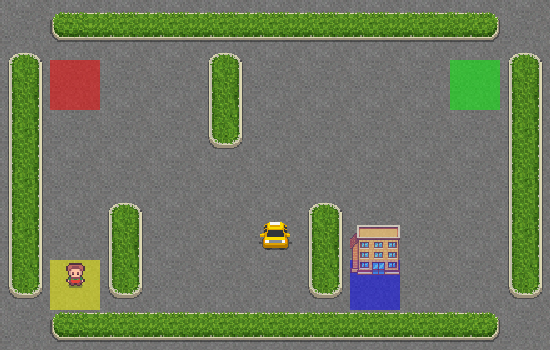

In [ ]:
env.render()

In [ ]:
#shahnawaz patel || 221A012 || 32
state

(351, {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

In [ ]:
#shahnawaz patel || 221A012 || 32
env.observation_space.n

np.int64(500)

In [ ]:
#shahnawaz patel || 221A012 || 32
env.action_space.n

np.int64(6)

In [ ]:
#shahnawaz patel || 221A012 || 32
env.observation_space.n

np.int64(500)

# **3.Possible Actions**

down(0),up(1),right(2),left(3),pickup(4),drop-off(5)

In [ ]:
#shahnawaz patel || 221A012 || 32
n_states=env.observation_space.n
n_actions=env.action_space.n

In [ ]:
#shahnawaz patel || 221A012 || 32
print(n_actions)

6


In [ ]:
#shahnawaz patel || 221A012 || 32
print(n_states)

500


In [ ]:
#shahnawaz patel || 221A012 || 32
env.step(1)


(251,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

# **4.How good does behaving completely random do?**

In [ ]:
#shahnawaz patel || 221A012 || 32
state=env.reset()
counter=0
g=0
reward=None

In [ ]:
#shahnawaz patel || 221A012 || 32
while reward !=20:
    state2, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated
    counter+=1
    g+=reward
    state=state2

In [ ]:
#shahnawaz patel || 221A012 || 32
print("Solved in {} steps with a total reward of {}".format(counter,g))

Solved in 438 steps with a total reward of -1470


# **5.Let's look at just one episode and see how the Q value changes after each step using the formula**

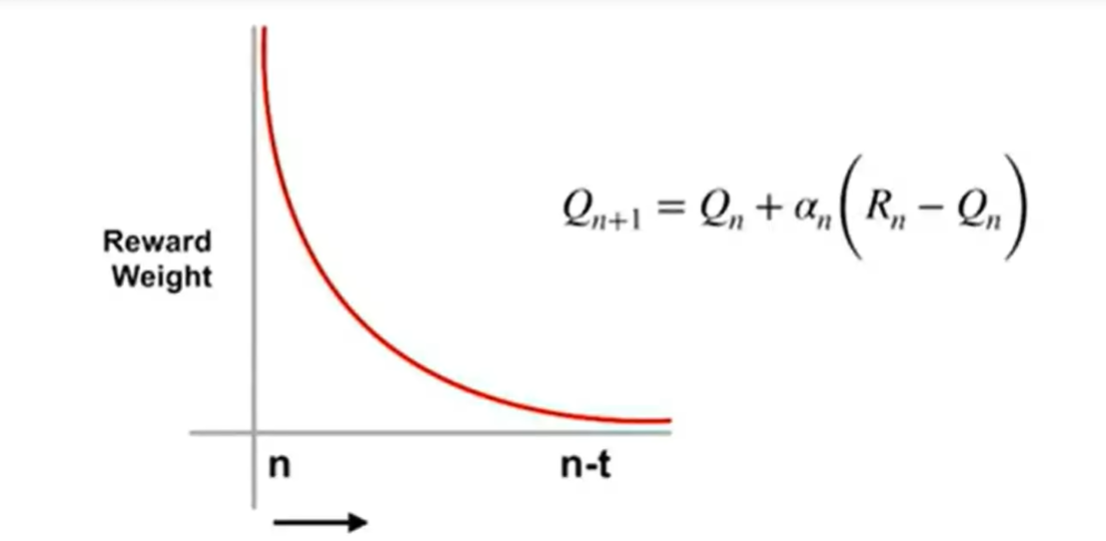

In [ ]:
#shahnawaz patel || 221A012 || 32
Q=np.zeros([n_states,n_actions])

In [ ]:
#shahnawaz patel || 221A012 || 32
np.shape(Q)

(500, 6)

In [ ]:
#shahnawaz patel || 221A012 || 32
n_actions

np.int64(6)

In [ ]:
#shahnawaz patel || 221A012 || 32
episodes=1
G=0
aplha=0.618

In [ ]:
#shahnawaz patel || 221A012 || 32
for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state, info = env.reset()
  finalState=state
  print("Inital State {}".format(state))
  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, terminated, truncated, info=env.step(action)
    Q[state, action] = Q[state, action] + aplha*(reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

Inital State 247


In [ ]:
#shahnawaz patel || 221A012 || 32
G

-787

In [ ]:
#shahnawaz patel || 221A012 || 32

episodes = 2000
rewardTracker = []

G = 0
alpha = 0.618

for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state, info = env.reset()
  finalState=state
  print("Inital State {}".format(state))

  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, terminated, truncated, info=env.step(action)
    Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

  if episode % 100 == 0:
    print('Episode {} Total Reward: {}'.format(episode,G))

Inital State 4
Inital State 271
Inital State 471
Inital State 474
Inital State 222
Inital State 131
Inital State 42
Inital State 148
Inital State 11
Inital State 421
Inital State 153
Inital State 234
Inital State 483
Inital State 402
Inital State 341
Inital State 313
Inital State 473
Inital State 394
Inital State 302
Inital State 494
Inital State 373
Inital State 12
Inital State 71
Inital State 262
Inital State 262
Inital State 354
Inital State 161
Inital State 387
Inital State 83
Inital State 422
Inital State 291
Inital State 331
Inital State 434
Inital State 371
Inital State 33
Inital State 312
Inital State 93
Inital State 253
Inital State 13
Inital State 244
Inital State 169
Inital State 429
Inital State 288
Inital State 194
Inital State 348
Inital State 7
Inital State 434
Inital State 61
Inital State 51
Inital State 123
Inital State 82
Inital State 329
Inital State 304
Inital State 204
Inital State 394
Inital State 81
Inital State 131
Inital State 401
Inital State 47
Inital State 1

In [ ]:
#shahnawaz patel || 221A012 || 32

G

15

# WE OBSERVE THAT AFTER 2000 EPISODE THE EXPECTED CUMULATIVE REWARD IS HIGHER THAN ONE EPISODE WHICH IS HIGHER THAN RANDOM EPISODE